In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
datafolder = "/Users/dajanakolarova/UOCHB OwnCloud/Ecoligase/DATA/DK018_HPLC"

# List of samples you want to load and plot
wanted_samples = [
"GTP 100E",
"GTP 0E",
"GMP 0E",
"GMP 100E",
]


In [8]:
def find_file_by_internal_name(folder, target_name):
    """"Searches through all .arw files in datafolder to find the one matching the internal name on line 2."""
    for filename in glob.glob(os.path.join(folder, "*.arw")):
            try:
                with open(filename, 'r', encoding='latin1') as f:
                    lines = [f.readline() for _ in range(3)]
                if len(lines) > 1:
                    exp_line = lines[1].strip()
                    parts = exp_line.split('\t')
                    if len(parts) > 1 and parts[1].replace('"', '').strip() == target_name:
                        return filename
            except Exception:
                continue
    return None

print("FOLDER SCAN – AVAILABLE SAMPLES FOUND INSIDE FILES:")

available_samples = []

for filename in glob.glob(os.path.join(datafolder, "*.arw")):
    try:
        with open(filename, 'r', encoding='latin1') as f:
            lines = [f.readline() for _ in range(3)]
        if len(lines) > 1:
            exp_line = lines[1].strip()
            parts = exp_line.split('\t')
            if len(parts) > 1 and parts[1] != '':
                internal_name = parts[1].replace('"', '').strip()
                available_samples.append(internal_name)
                print(f'"{internal_name}",')
    except Exception:
        continue

print("=" * 65)

print("DATA LOADED:")
loaded_data = []

for sample_name in wanted_samples:
    filepath = find_file_by_internal_name(datafolder, sample_name)
    if not filepath:
        print(f"Sample '{sample_name}' was not found in any file")
        continue
        
    try:
        df = pd.read_csv(filepath, skiprows=2, header=None, sep=None, engine='python')
        if df.shape[1] >= 2:
            df = df.iloc[:, :2]
            df.columns = ["Time", "Abs"]
            df["Sample_Name"] = sample_name
            loaded_data.append(df)
            print(f"{sample_name}")
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

if not loaded_data:
    print("No data could be loaded.")
else:
    all_data = pd.concat(loaded_data, ignore_index=True)
    sns.set_theme(style="ticks")

FOLDER SCAN – AVAILABLE SAMPLES FOUND INSIDE FILES:
"GTP 0E",
"GMP 100E",
"RNA  ATP",
"ATP",
"GTP 100E",
"RNA  ATP E",
"SAP ATP",
"NAD 100E",
"GMP 0E",
"NAD 0E",
"CS adenine",
"bkank",
DATA LOADED:
✅GTP 100E
✅GTP 0E
✅GMP 0E
✅GMP 100E


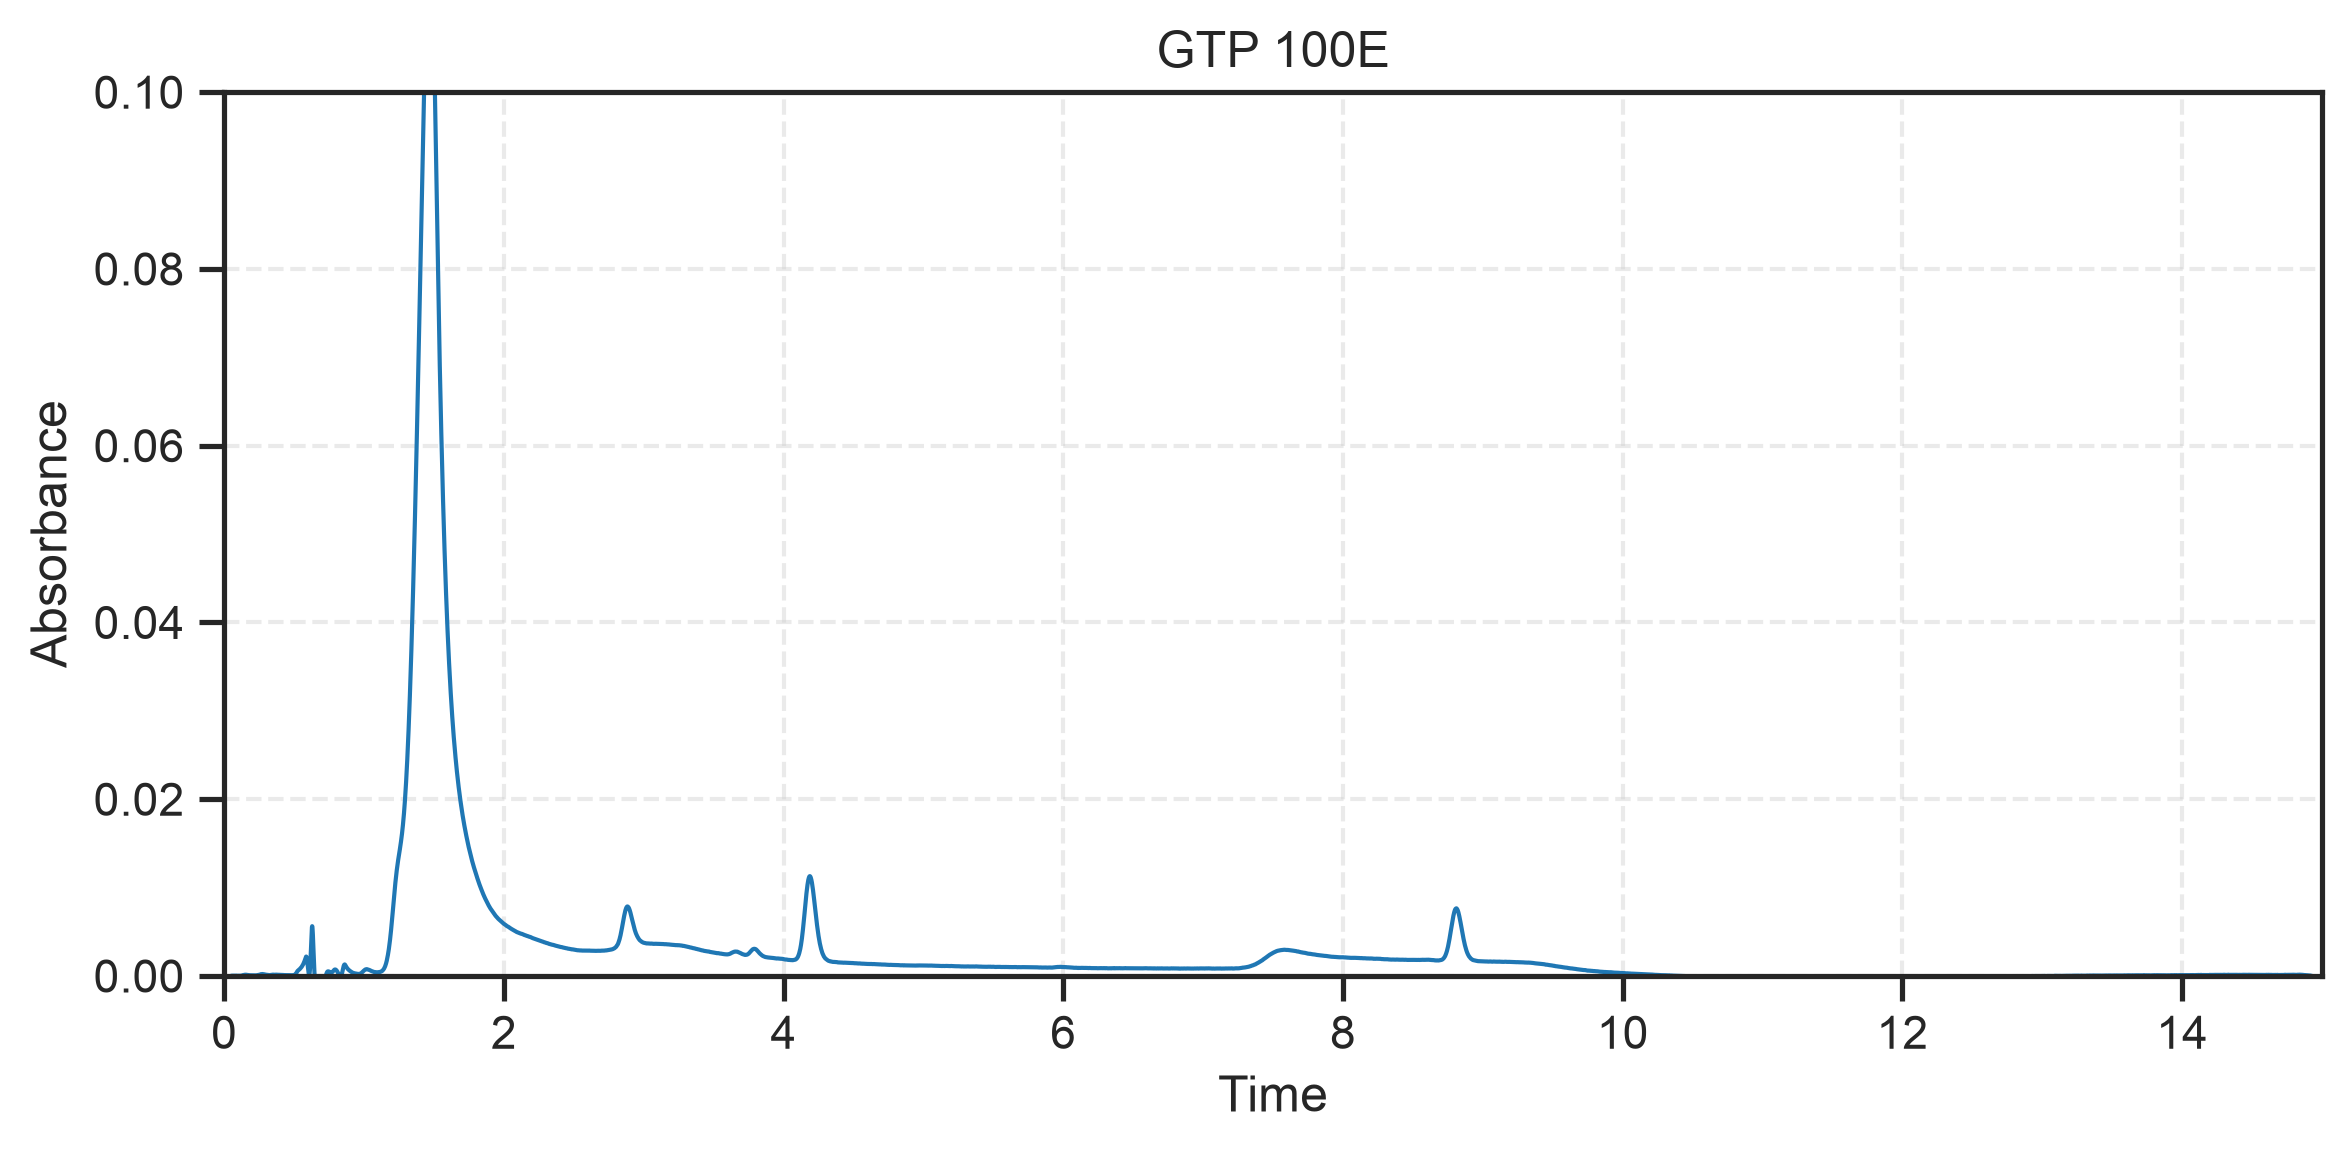

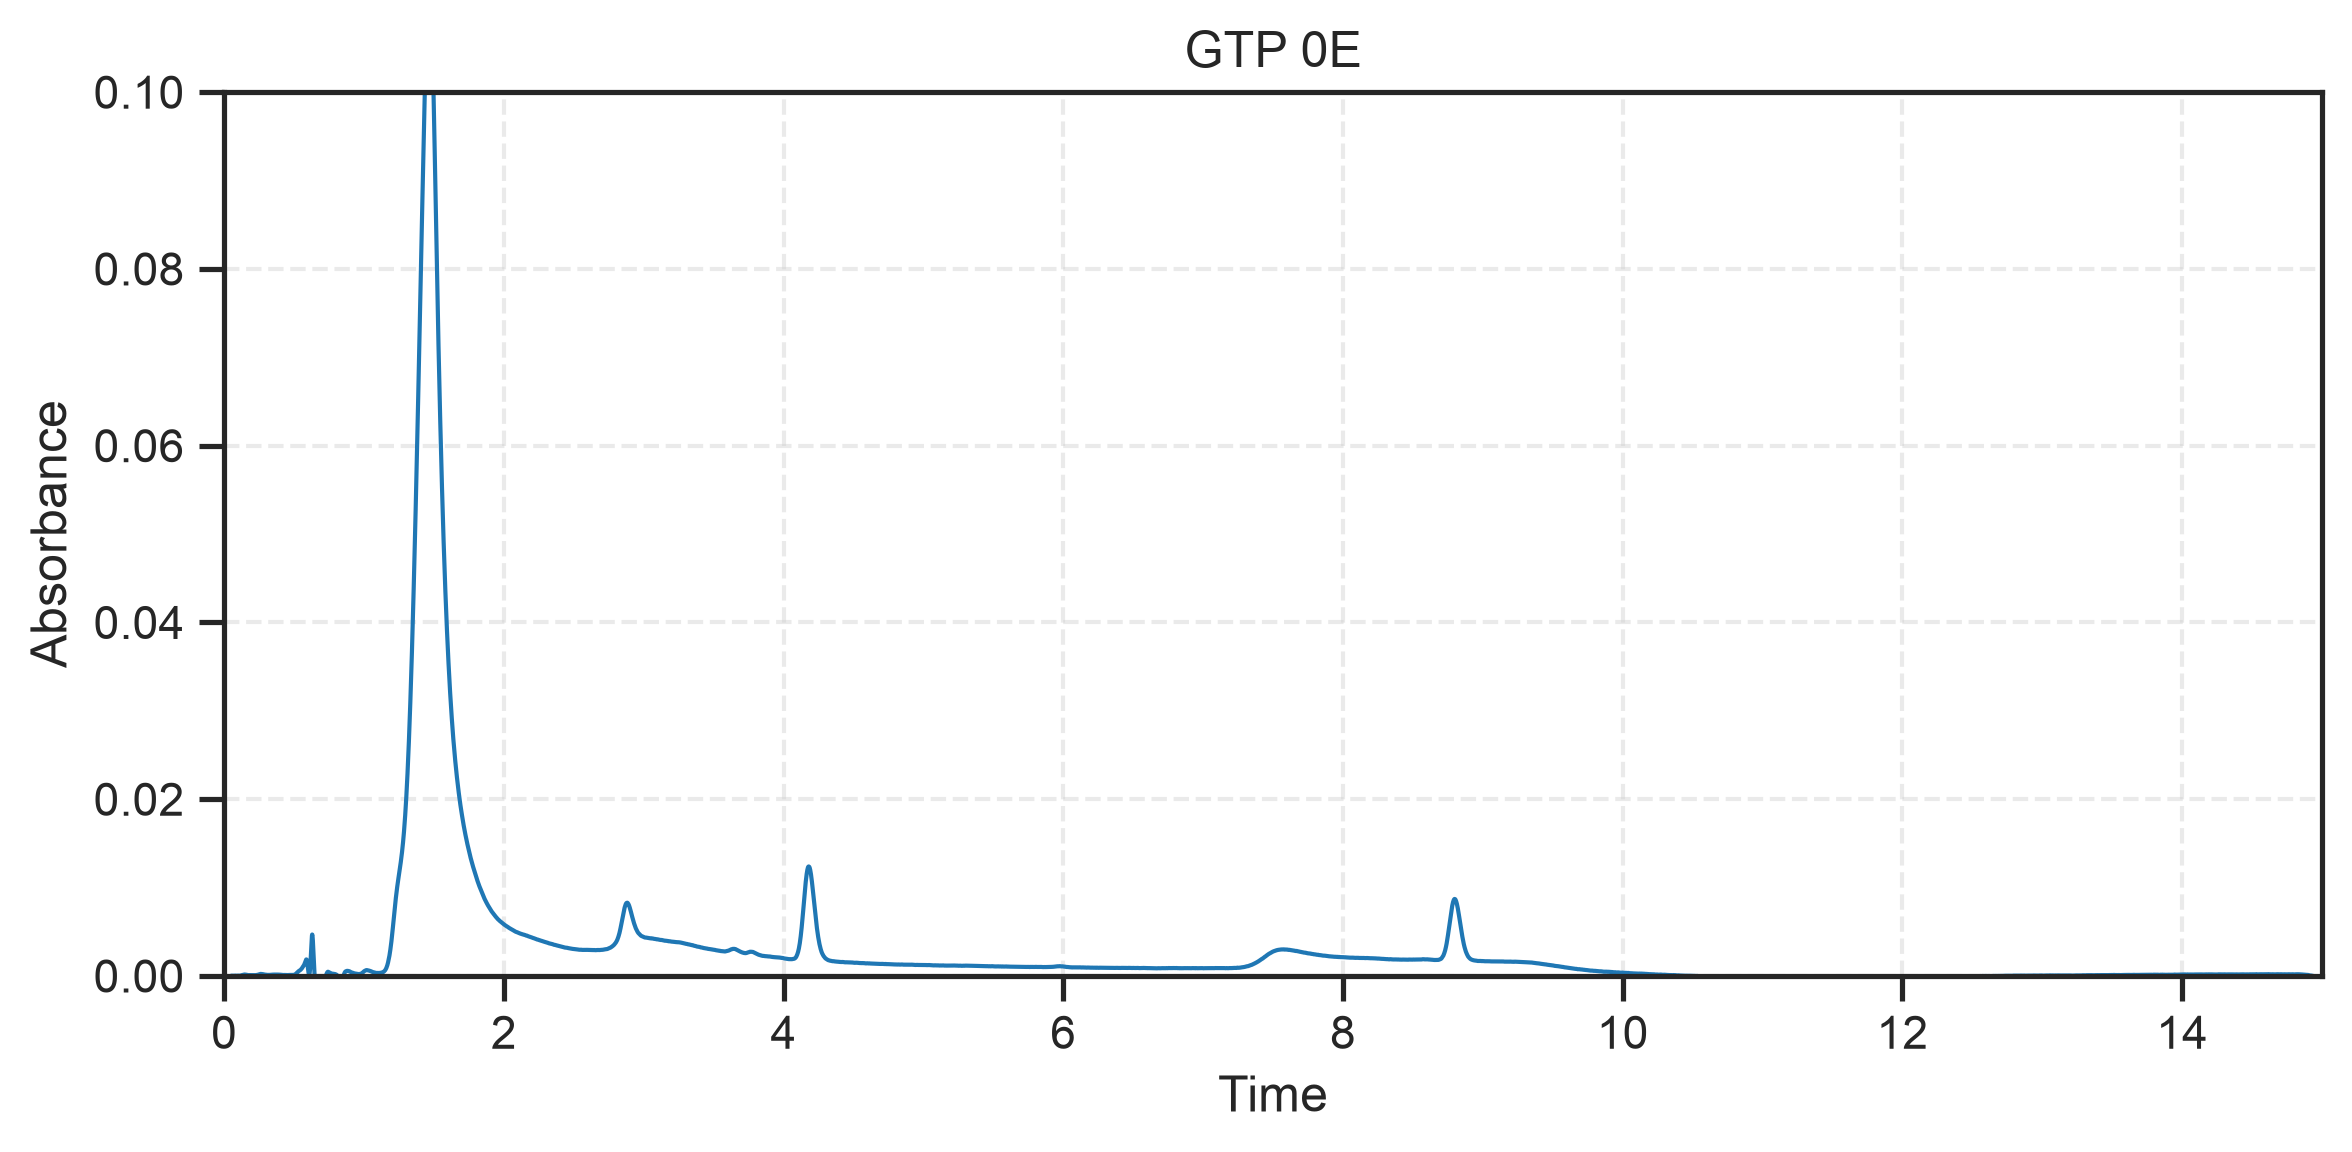

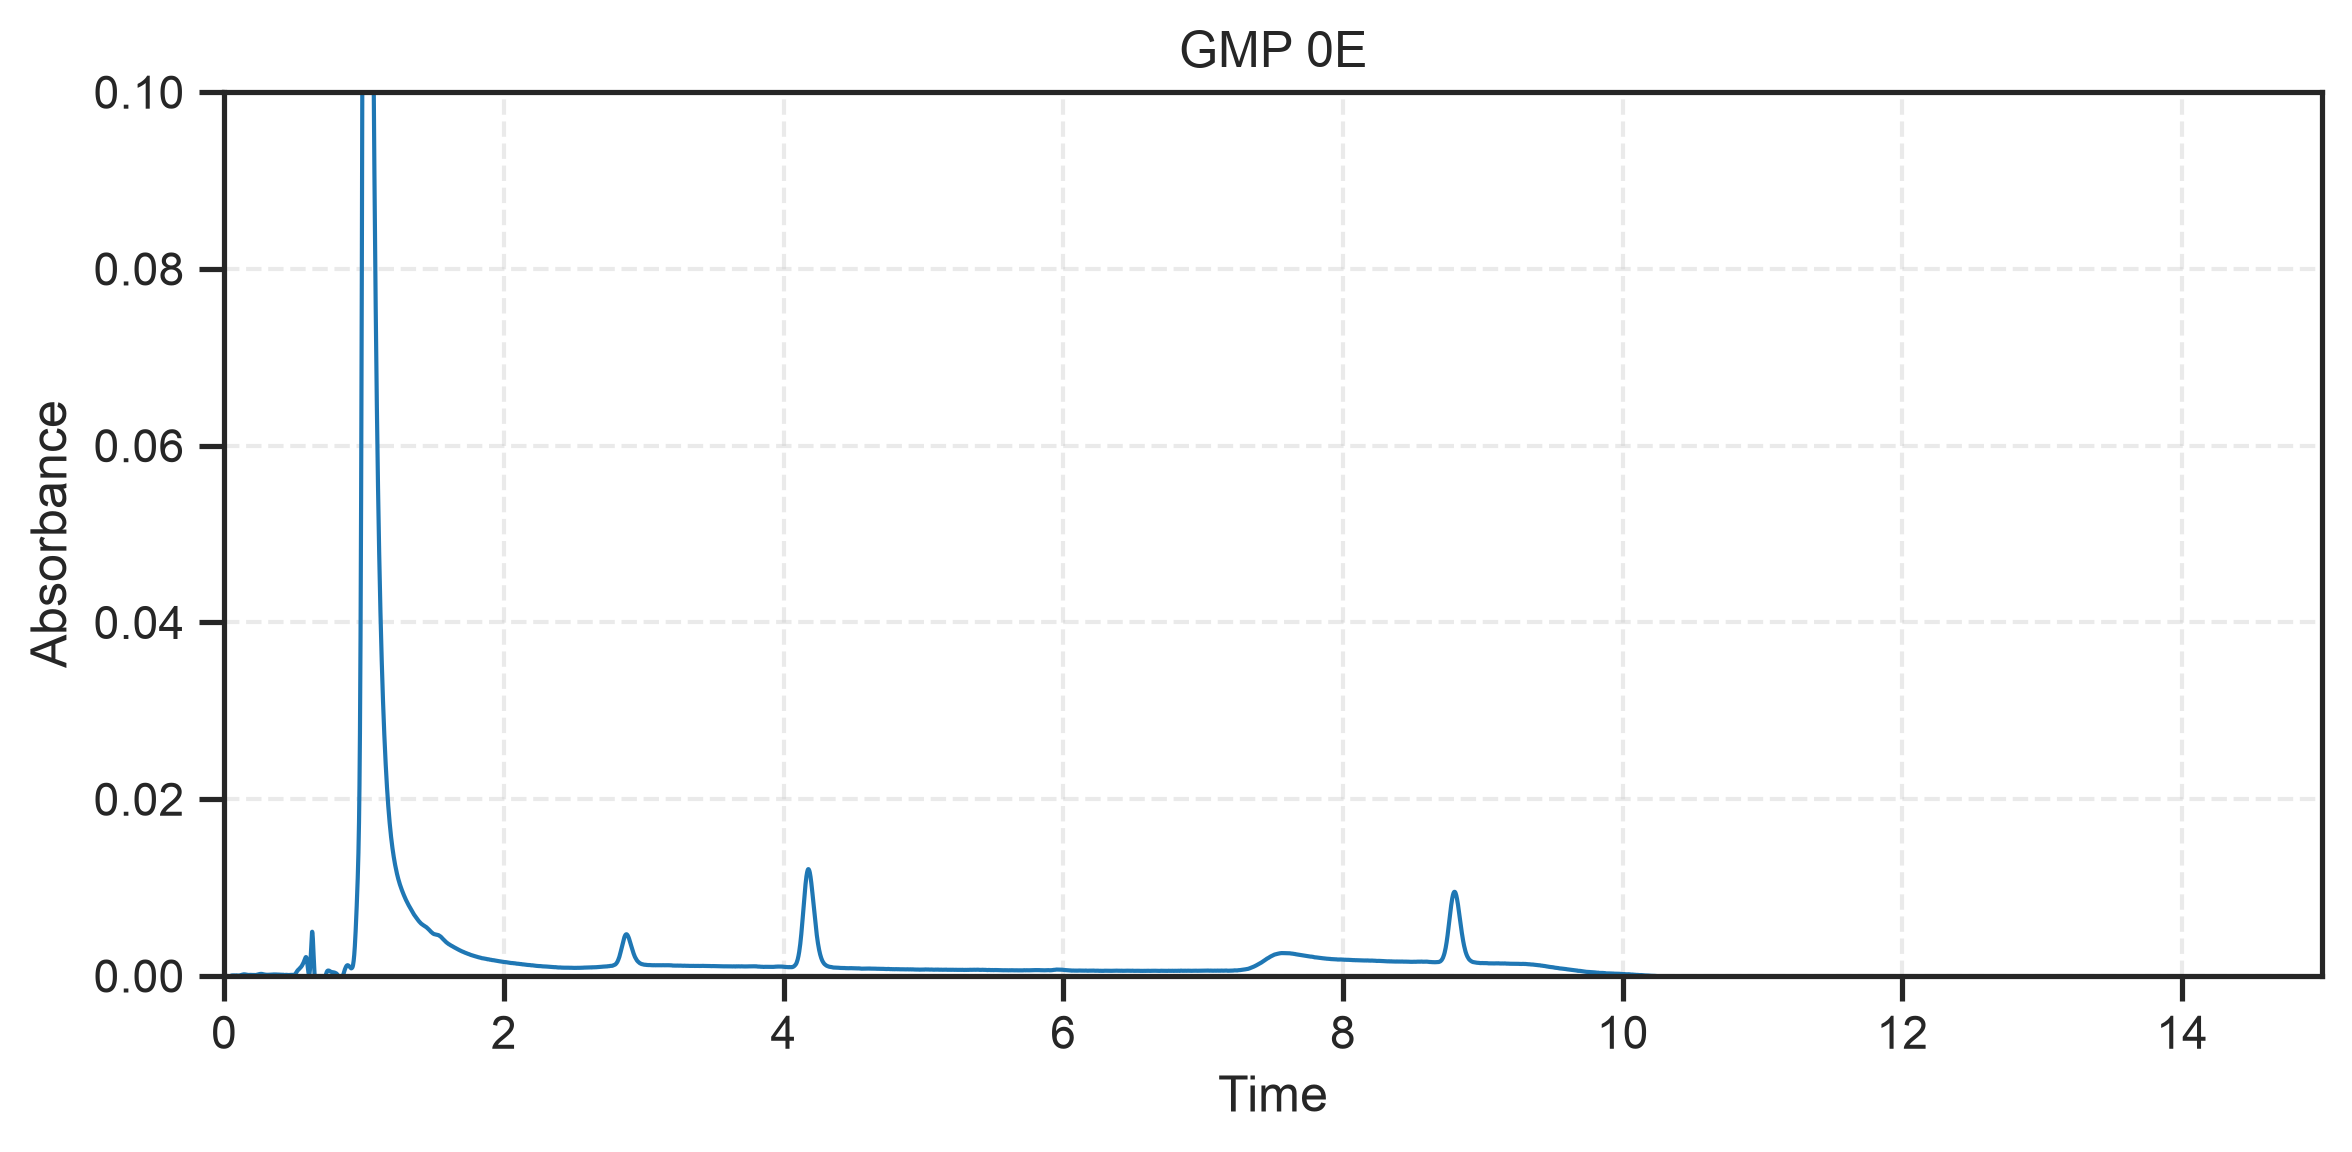

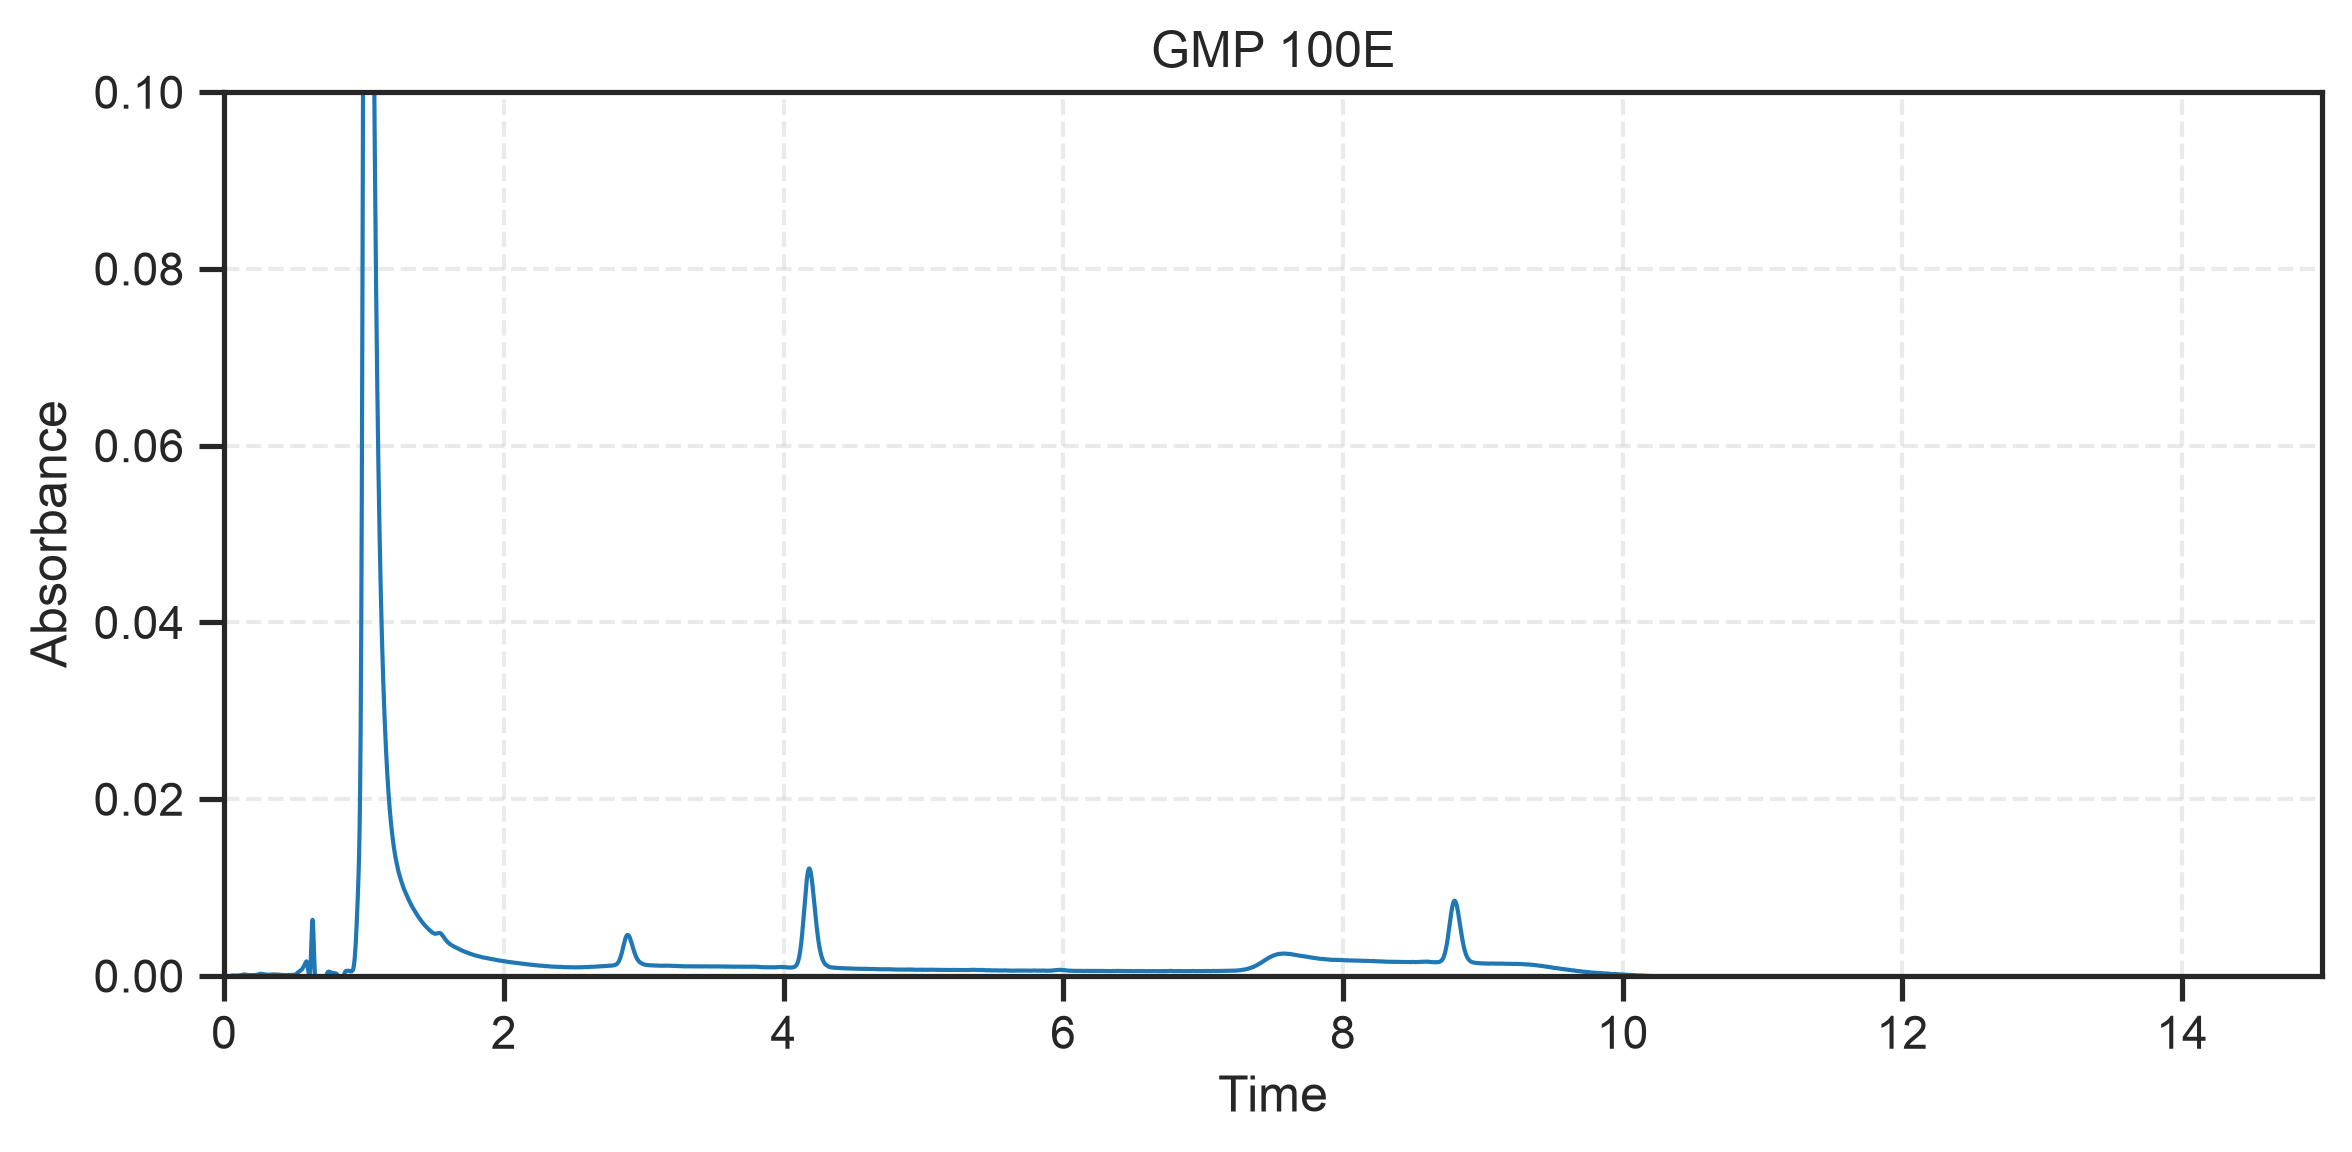

In [9]:
# n graphs for n selected samples

for sample_name in wanted_samples:
    subset = all_data[all_data["Sample_Name"] == sample_name]
    if subset.empty:
        continue
            
    plt.figure(figsize=(8, 4), dpi=300)
    plt.plot(subset["Time"], subset["Abs"], color="tab:blue", linewidth=1.0)
        
    plt.xlim(0, 15)
    plt.ylim(0, 0.1)
    plt.xlabel("Time")
    plt.ylabel("Absorbance")
    plt.title(f"{sample_name}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [10]:
safe_filename = sample_name.replace(" ", "_") + ".png"
plt.savefig(safe_filename, dpi=300)
print(f"💾Saved as: {safe_filename}")

💾 Uloženo jako: ATP_100E_37C.png


<Figure size 640x480 with 0 Axes>

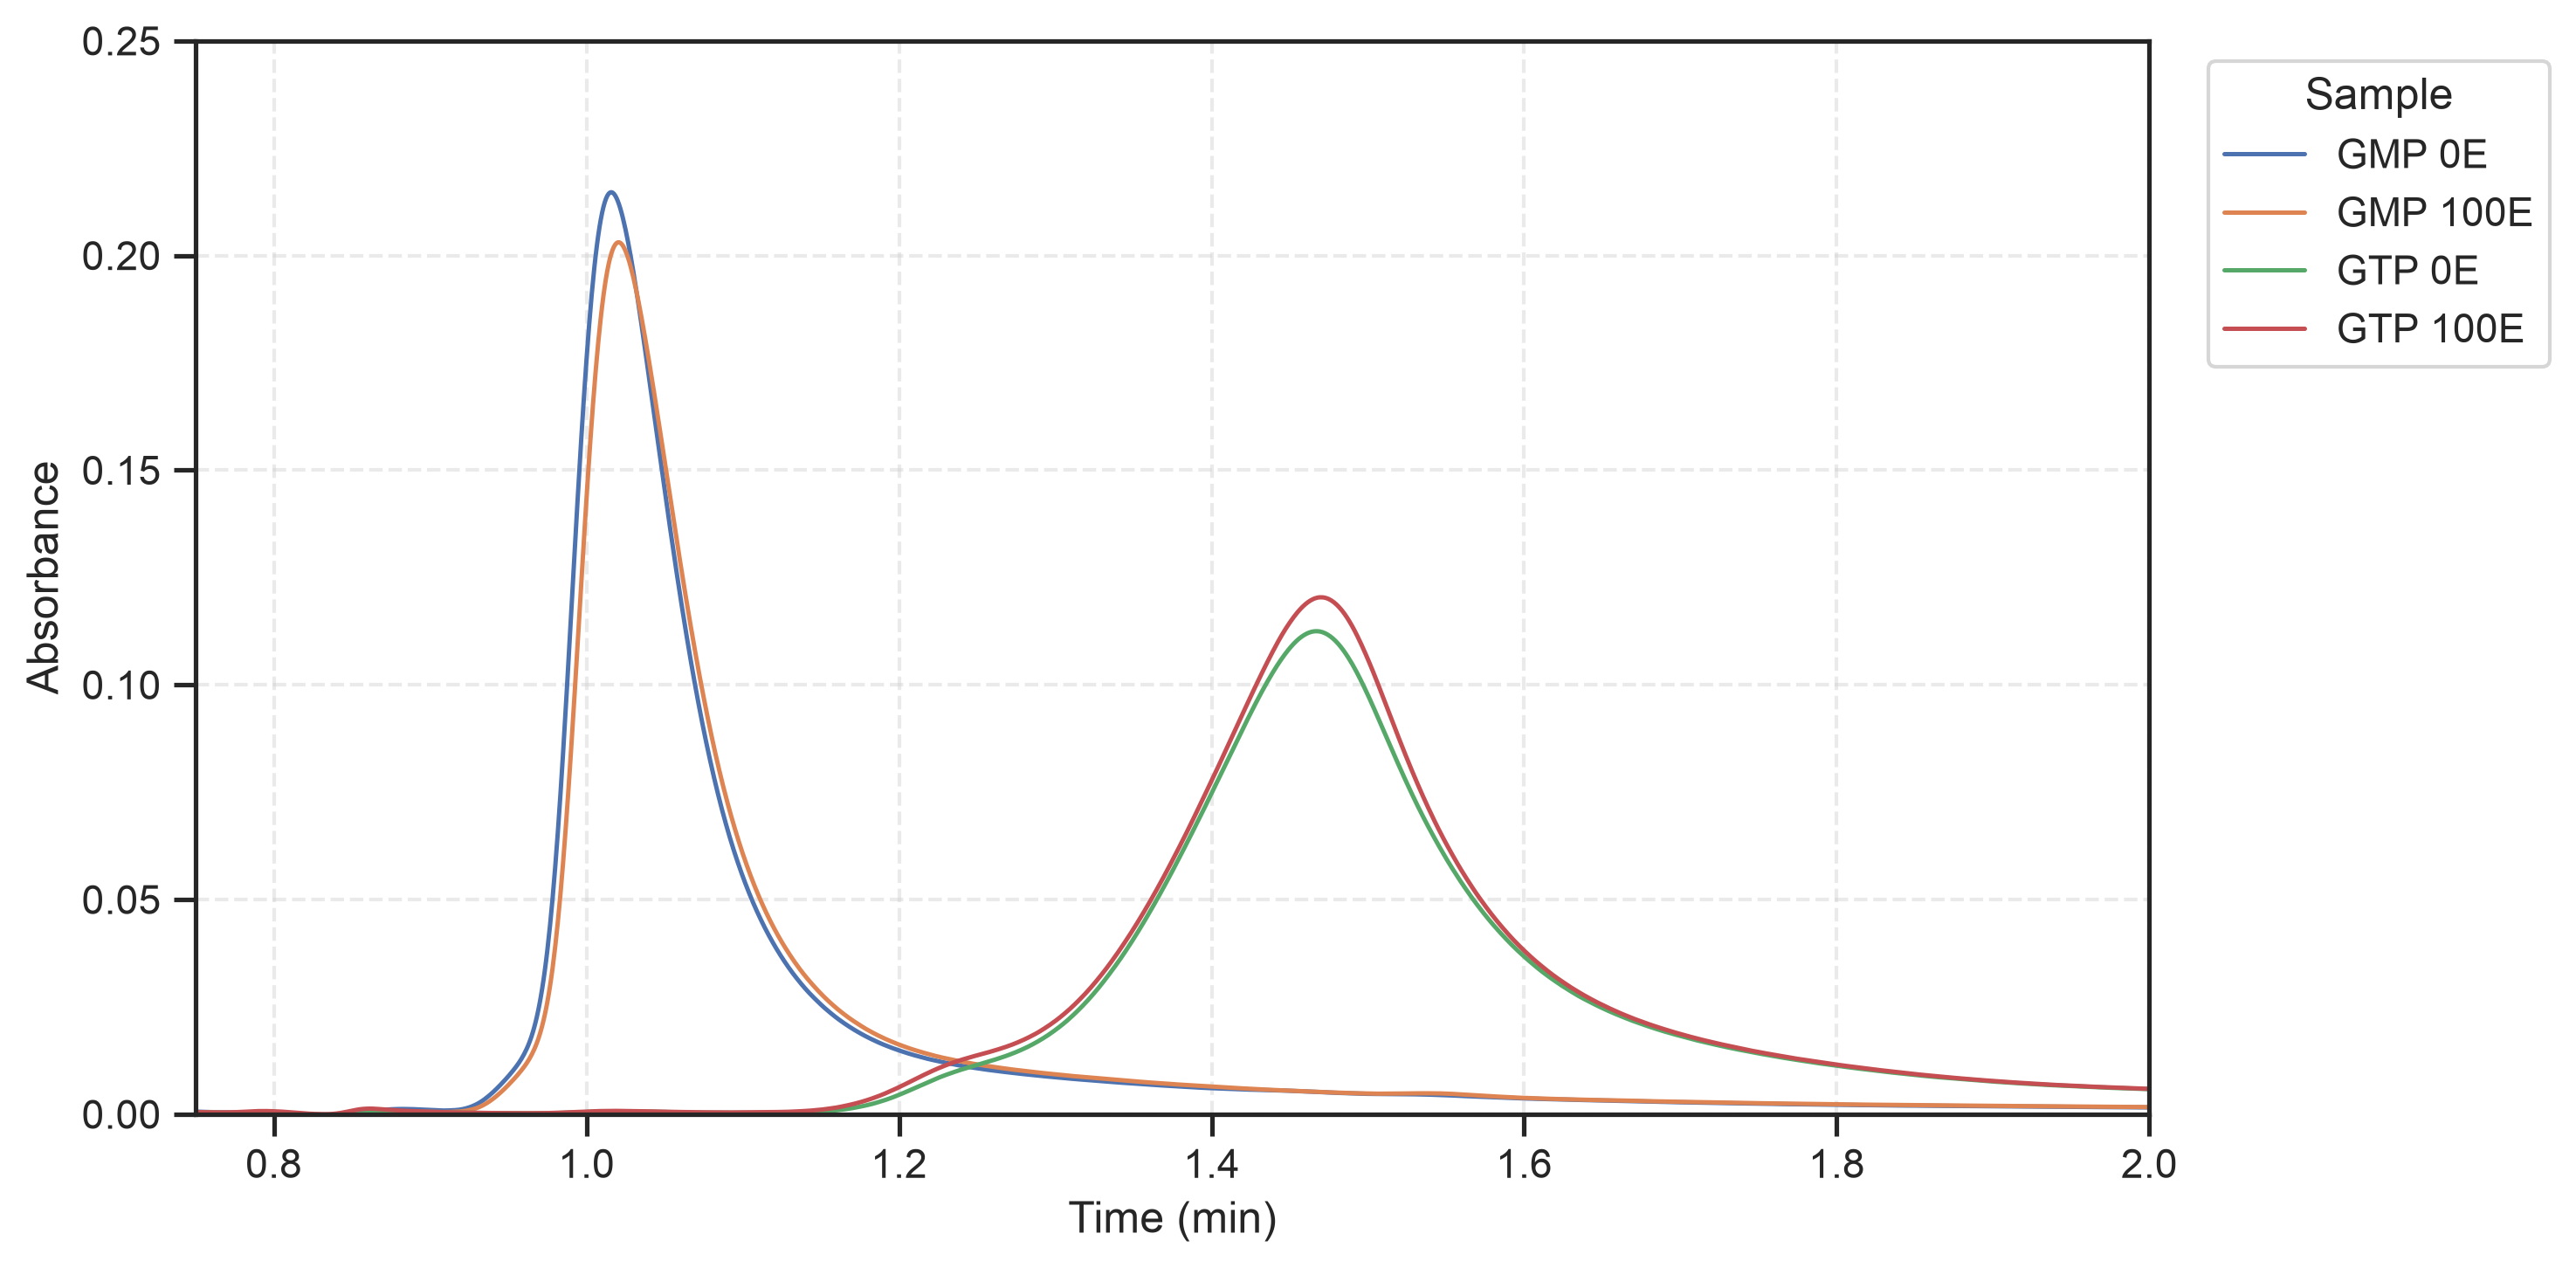

In [96]:
# 1 graph for all selected samples
# Custom visual style for each sample (Color & Line Style)
# Available styles: '-', '--', '-.', ':' 
style_config = {
    # "Sample Name": {"color": "green", "linestyle": ":"}
}

plt.figure(figsize=(10, 5), dpi=300)
    
for sample_name, group in all_data.groupby("Sample_Name"):
        cfg = style_config.get(sample_name, {"color": None, "linestyle": "-"})
        
        plt.plot(
            group["Time"], 
            group["Abs"], 
            label=sample_name, 
            color=cfg["color"], 
            linestyle=cfg["linestyle"], 
            linewidth=1.2
        )
        
plt.xlim(0.75, 2)
plt.ylim(0, 0.25)
plt.xlabel("Time (min)")
plt.ylabel("Absorbance")
plt.title("")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Sample", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
safe_filename = sample_name.replace(" ", "_") + ".png"
plt.savefig(safe_filename, dpi=300)
print(f"💾Saved as: {safe_filename}")

💾 Uloženo jako: AMP_100E_37C.png


<Figure size 640x480 with 0 Axes>